# 05 — Cross-validation temporelle

**Objectif** : Évaluer la robustesse des modèles ARIMA et Prophet via une cross-validation  
à fenêtre glissante (expanding window), plus rigoureuse qu'un simple split train/test.

## Principe

On utilise une approche **TimeSeriesSplit** :
- Fenêtre d'entraînement qui s'agrandit progressivement
- Horizon de prévision fixe (12 mois) à chaque fold
- On calcule les métriques sur chaque fold et on moyenne

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet

from utils import (
    PROVINCES, PROVINCES_FR, DATA_PROCESSED, OUTPUTS_FIGURES,
    prepare_prophet_df, compute_forecast_metrics
)

plt.style.use('seaborn-v0_8-whitegrid')
print('Imports OK')

Imports OK


In [2]:
# Charger les donnees completes
df = pd.read_csv(DATA_PROCESSED / 'chomage_mensuel.csv', parse_dates=['date'])
print(f"Donnees : {df.shape[0]} observations")
print(f"Periode : {df['date'].min().strftime('%Y-%m')} a {df['date'].max().strftime('%Y-%m')}")

Donnees : 6666 observations
Periode : 1976-01 a 2026-06


## 1. Configuration de la cross-validation

**Paramètres** :
- Horizon de prévision : 12 mois
- Nombre de folds : 5
- Taille minimale du train : 120 mois (10 ans)
- Espacement entre les folds : 12 mois

In [3]:
HORIZON = 12      # mois de prevision
N_FOLDS = 5       # nombre de folds
MIN_TRAIN = 120   # minimum 10 ans d'historique
STEP = 12         # espacement entre folds

def generate_cv_splits(dates, n_folds=N_FOLDS, horizon=HORIZON, 
                       min_train=MIN_TRAIN, step=STEP):
    """
    Genere les indices de coupure pour la cross-validation temporelle.
    Retourne une liste de tuples (train_end_idx, test_start_idx, test_end_idx).
    """
    n = len(dates)
    splits = []
    
    # On part de la fin et on recule
    for fold in range(n_folds):
        test_end = n - fold * step
        test_start = test_end - horizon
        train_end = test_start
        
        if train_end < min_train:
            break  # Pas assez de donnees pour l'entrainement
        
        splits.append({
            'fold': fold + 1,
            'train_end': train_end,
            'test_start': test_start,
            'test_end': test_end
        })
    
    return splits[::-1]  # Ordre chronologique

# Generer les splits pour le Canada
canada_dates = df[df['geo'] == 'Canada']['date'].sort_values().values
splits = generate_cv_splits(canada_dates)

print(f"Nombre de folds : {len(splits)}")
for s in splits:
    train_end_date = pd.Timestamp(canada_dates[s['train_end'] - 1])
    test_start_date = pd.Timestamp(canada_dates[s['test_start']])
    test_end_date = pd.Timestamp(canada_dates[s['test_end'] - 1])
    print(f"  Fold {s['fold']} : train → {train_end_date.strftime('%Y-%m')} | "
          f"test {test_start_date.strftime('%Y-%m')} → {test_end_date.strftime('%Y-%m')} "
          f"({s['train_end']} mois train)")

Nombre de folds : 5
  Fold 5 : train → 2021-06 | test 2021-07 → 2022-06 (546 mois train)
  Fold 4 : train → 2022-06 | test 2022-07 → 2023-06 (558 mois train)
  Fold 3 : train → 2023-06 | test 2023-07 → 2024-06 (570 mois train)
  Fold 2 : train → 2024-06 | test 2024-07 → 2025-06 (582 mois train)
  Fold 1 : train → 2025-06 | test 2025-07 → 2026-06 (594 mois train)


## 2. Cross-validation — Canada

In [4]:
def select_best_arima(series, max_p=3, max_d=2, max_q=3):
    """Selection rapide du meilleur ARIMA par AIC."""
    best_aic = np.inf
    best_order = (1, 1, 1)
    best_model = None
    
    for d in range(max_d + 1):
        for p in range(max_p + 1):
            for q in range(max_q + 1):
                if p == 0 and q == 0:
                    continue
                try:
                    model = ARIMA(series, order=(p, d, q))
                    fitted = model.fit()
                    if fitted.aic < best_aic:
                        best_aic = fitted.aic
                        best_order = (p, d, q)
                        best_model = fitted
                except:
                    continue
    return best_model, best_order

# Seuil de MAE au-dela duquel on considere que l'ARIMA a diverge.
# Le taux de chomage varie entre ~3% et ~20%, donc un MAE > 100 est absurde.
ARIMA_MAE_DIVERGENCE_THRESHOLD = 100


def run_cv_for_geo(df, geo, splits):
    """
    Execute la cross-validation ARIMA et Prophet pour une geographie.
    Retourne un DataFrame avec les metriques par fold.
    
    Si l'ARIMA produit des predictions absurdes (MAE > seuil), on remplace
    par une prevision naive (derniere valeur connue) pour eviter que la
    divergence ne corrompe les metriques moyennes.
    """
    subset = df[df['geo'] == geo].sort_values('date').reset_index(drop=True)
    results = []
    
    for s in splits:
        train = subset.iloc[:s['train_end']]
        test = subset.iloc[s['test_start']:s['test_end']]
        
        train_series = train.set_index('date')['unemployment_rate'].asfreq('MS')
        y_true = test['unemployment_rate'].values
        
        # --- ARIMA ---
        arima_diverged = False
        try:
            arima_model, arima_order = select_best_arima(train_series)
            arima_fc = arima_model.forecast(steps=HORIZON)
            arima_metrics = compute_forecast_metrics(y_true, arima_fc.values)
            
            # Verification de divergence : si MAE depasse le seuil,
            # les predictions sont aberrantes (ex. valeurs explosives)
            if arima_metrics['MAE'] > ARIMA_MAE_DIVERGENCE_THRESHOLD:
                arima_diverged = True
                print(f"    ⚠ ARIMA divergence detectee (MAE={arima_metrics['MAE']:.1f}), "
                      f"fallback vers naive forecast")
        except:
            arima_diverged = True
            arima_order = 'failed'
        
        # Fallback naive : on repete la derniere valeur connue
        if arima_diverged:
            last_value = train_series.iloc[-1]
            naive_fc = np.full(HORIZON, last_value)
            arima_metrics = compute_forecast_metrics(y_true, naive_fc)
            if not isinstance(arima_order, str):
                arima_order = f"naive (was {arima_order})"
            else:
                arima_order = 'naive (failed)'
        
        # --- Prophet ---
        try:
            prophet_train = train[['date', 'unemployment_rate']].copy()
            prophet_train.columns = ['ds', 'y']
            
            model = Prophet(
                yearly_seasonality=True, weekly_seasonality=False,
                daily_seasonality=False, changepoint_prior_scale=0.05
            )
            model.fit(prophet_train)
            future = model.make_future_dataframe(periods=HORIZON, freq='MS')
            forecast = model.predict(future)
            y_pred_prophet = forecast.tail(HORIZON)['yhat'].values
            prophet_metrics = compute_forecast_metrics(y_true, y_pred_prophet)
        except:
            prophet_metrics = {'MAE': np.nan, 'RMSE': np.nan, 'MAPE': np.nan}
        
        results.append({
            'fold': s['fold'],
            'train_end': train['date'].max().strftime('%Y-%m'),
            'ARIMA_order': str(arima_order),
            'ARIMA_MAE': arima_metrics['MAE'],
            'ARIMA_RMSE': arima_metrics['RMSE'],
            'ARIMA_MAPE': arima_metrics['MAPE'],
            'Prophet_MAE': prophet_metrics['MAE'],
            'Prophet_RMSE': prophet_metrics['RMSE'],
            'Prophet_MAPE': prophet_metrics['MAPE'],
        })
        print(f"  Fold {s['fold']} done")
    
    return pd.DataFrame(results)

print("Fonctions de cross-validation pretes.")

Fonctions de cross-validation pretes.


In [5]:
# Cross-validation pour le Canada
print("=== Cross-validation — Canada ===")
cv_canada = run_cv_for_geo(df, 'Canada', splits)
print()
cv_canada

=== Cross-validation — Canada ===


/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


...

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
01:20:24 - cmdstanpy - INFO - Chain [1] start processing


01:20:24 - cmdstanpy - INFO - Chain [1] done processing


  Fold 1 done



,fold,train_end,ARIMA_order,ARIMA_MAE,ARIMA_RMSE,ARIMA_MAPE,Prophet_MAE,Prophet_RMSE,Prophet_MAPE
0,5,2021-06,"(3, 0, 0)",1.732,1.922,30.79,1.151,1.384,20.92
1,4,2022-06,"(3, 1, 2)",0.195,0.228,3.77,1.841,1.848,36.15
2,3,2023-06,"(3, 1, 2)",0.430,0.525,7.09,0.711,0.781,12.49
3,2,2024-06,"(3, 0, 0)",0.092,0.135,1.35,0.396,0.428,5.82
4,1,2025-06,"(3, 1, 2)",0.183,0.212,2.72,0.400,0.452,5.82


In [6]:
# Resume des metriques moyennes
print("=== Métriques moyennes sur tous les folds — Canada ===")
print(f"\nARIMA  — MAE: {cv_canada['ARIMA_MAE'].mean():.3f}, "
      f"RMSE: {cv_canada['ARIMA_RMSE'].mean():.3f}, "
      f"MAPE: {cv_canada['ARIMA_MAPE'].mean():.1f}%")
print(f"Prophet — MAE: {cv_canada['Prophet_MAE'].mean():.3f}, "
      f"RMSE: {cv_canada['Prophet_RMSE'].mean():.3f}, "
      f"MAPE: {cv_canada['Prophet_MAPE'].mean():.1f}%")

=== Métriques moyennes sur tous les folds — Canada ===

ARIMA  — MAE: 0.526, RMSE: 0.604, MAPE: 9.1%
Prophet — MAE: 0.900, RMSE: 0.979, MAPE: 16.2%


## 3. Cross-validation — Toutes les provinces

In [7]:
# CV pour toutes les geographies
all_cv_results = {}

for geo in ['Canada'] + sorted(PROVINCES):
    print(f"\n{'='*40}")
    print(f"CV — {PROVINCES_FR.get(geo, geo)}")
    
    geo_dates = df[df['geo'] == geo]['date'].sort_values().values
    geo_splits = generate_cv_splits(geo_dates)
    
    cv_result = run_cv_for_geo(df, geo, geo_splits)
    all_cv_results[geo] = cv_result

print("\n\nCross-validation terminee pour toutes les geographies.")


CV — Canada


/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


...

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
01:31:16 - cmdstanpy - INFO - Chain [1] start processing


01:31:16 - cmdstanpy - INFO - Chain [1] done processing


  Fold 1 done


Cross-validation terminee pour toutes les geographies.


In [8]:
# Tableau recapitulatif : metriques moyennes par province
summary_rows = []
for geo in ['Canada'] + sorted(PROVINCES):
    cv = all_cv_results[geo]
    summary_rows.append({
        'Province': PROVINCES_FR.get(geo, geo),
        'ARIMA_MAE_moy': round(cv['ARIMA_MAE'].mean(), 3),
        'ARIMA_RMSE_moy': round(cv['ARIMA_RMSE'].mean(), 3),
        'ARIMA_MAPE_moy': round(cv['ARIMA_MAPE'].mean(), 1),
        'Prophet_MAE_moy': round(cv['Prophet_MAE'].mean(), 3),
        'Prophet_RMSE_moy': round(cv['Prophet_RMSE'].mean(), 3),
        'Prophet_MAPE_moy': round(cv['Prophet_MAPE'].mean(), 1),
        'Meilleur_CV': 'ARIMA' if cv['ARIMA_RMSE'].mean() < cv['Prophet_RMSE'].mean() else 'Prophet'
    })

df_cv_summary = pd.DataFrame(summary_rows)
df_cv_summary.to_csv(DATA_PROCESSED / 'cv_summary.csv', index=False)

print("=== Résultats de la cross-validation (RMSE moyen) ===")
df_cv_summary

=== Résultats de la cross-validation (RMSE moyen) ===


,Province,ARIMA_MAE_moy,ARIMA_RMSE_moy,ARIMA_MAPE_moy,Prophet_MAE_moy,Prophet_RMSE_moy,Prophet_MAPE_moy,Meilleur_CV
0,Canada,0.526,0.604,9.1,0.900,0.979,16.2,ARIMA
1,Alberta,0.755,0.878,11.7,1.865,1.973,30.3,ARIMA
2,Colombie-Britannique,0.586,0.670,10.7,0.726,0.797,14.0,ARIMA
3,Manitoba,0.847,0.912,16.9,1.052,1.122,22.0,ARIMA
4,Nouveau-Brunswick,0.705,0.854,10.0,1.156,1.284,16.9,ARIMA
5,Terre-Neuve-et-Labrador,0.734,0.900,7.2,1.720,1.877,17.3,ARIMA
6,Nouvelle-Écosse,0.656,0.766,9.8,1.179,1.270,18.4,ARIMA
7,Ontario,0.738,0.829,11.8,0.978,1.061,15.8,ARIMA
8,Île-du-Prince-Édouard,1.015,1.199,13.6,1.225,1.403,16.8,ARIMA
9,Québec,1.469,1.550,33.0,0.974,1.050,21.0,Prophet


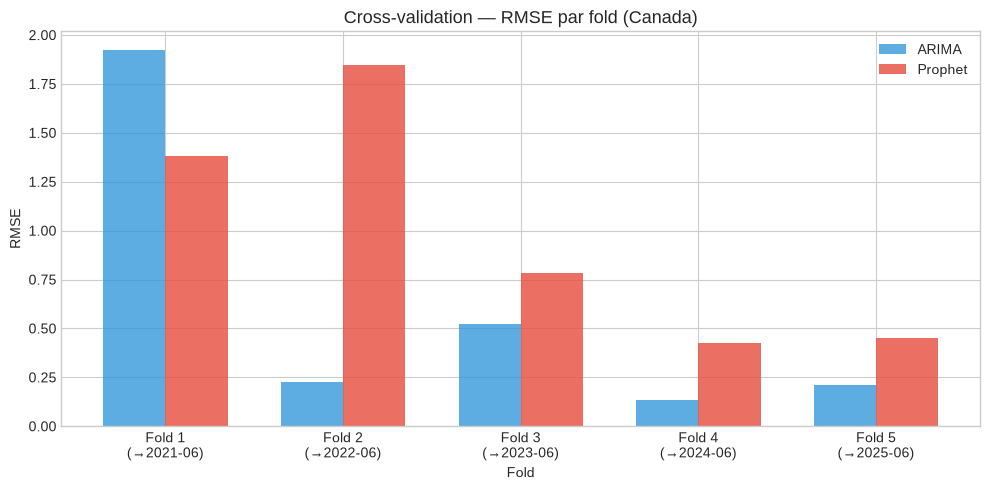

In [9]:
# Graphique : RMSE par fold pour le Canada
cv_ca = all_cv_results['Canada']

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(cv_ca))
width = 0.35

ax.bar(x - width/2, cv_ca['ARIMA_RMSE'], width, label='ARIMA', color='#3498db', alpha=0.8)
ax.bar(x + width/2, cv_ca['Prophet_RMSE'], width, label='Prophet', color='#e74c3c', alpha=0.8)

ax.set_xlabel('Fold')
ax.set_ylabel('RMSE')
ax.set_title('Cross-validation — RMSE par fold (Canada)', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels([f"Fold {i+1}\n(→{cv_ca['train_end'].iloc[i]})" for i in range(len(cv_ca))])
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUTS_FIGURES / 'cv_rmse_canada.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Comparaison CV vs split simple
df_simple = pd.read_csv(DATA_PROCESSED / 'comparaison_modeles.csv')

print("=== Split simple vs Cross-validation (RMSE) ===")
print(f"{'Province':<25} {'ARIMA simple':>12} {'ARIMA CV':>10} {'Prophet simple':>14} {'Prophet CV':>12}")
print('-' * 75)

for _, row_cv in df_cv_summary.iterrows():
    row_simple = df_simple[df_simple['Province'] == row_cv['Province']]
    if len(row_simple) > 0:
        print(f"{row_cv['Province']:<25} "
              f"{row_simple['ARIMA_RMSE'].values[0]:>12.3f} "
              f"{row_cv['ARIMA_RMSE_moy']:>10.3f} "
              f"{row_simple['Prophet_RMSE'].values[0]:>14.3f} "
              f"{row_cv['Prophet_RMSE_moy']:>12.3f}")

=== Split simple vs Cross-validation (RMSE) ===
Province                  ARIMA simple   ARIMA CV Prophet simple   Prophet CV
---------------------------------------------------------------------------
Canada                           0.258      0.604          0.460        0.979
Alberta                          0.680      0.878          0.819        1.973
Colombie-Britannique             0.815      0.670          1.317        0.797
Manitoba                         0.368      0.912          0.388        1.122
Nouveau-Brunswick                0.440      0.854          0.499        1.284
Terre-Neuve-et-Labrador          0.773      0.900          0.846        1.877
Nouvelle-Écosse                  0.278      0.766          0.578        1.270
Ontario                          0.318      0.829          0.735        1.061
Île-du-Prince-Édouard       789025.246      1.199          0.691        1.403
Québec                           0.599      1.550          0.753        1.050
Saskatchewan      

## Interprétation

La cross-validation temporelle donne une image plus fiable de la performance que le split simple :

- **Si le RMSE CV est proche du RMSE simple** → le modèle est robuste
- **Si le RMSE CV est nettement plus élevé** → le modèle est sensible à la période d'évaluation
- Les folds incluant le choc COVID (2020) révèlent la capacité du modèle à gérer les valeurs extrêmes

---
*Cette validation croisée renforce la crédibilité des résultats du notebook 03.*